# Exploratory Data Analysis — Credit Risk Pipeline


This notebook covers:
1. Environment setup & data loading
2. Dataset 1 — application_record + credit_record (Primary)
3. Dataset 2 — credit_risk_dataset (Secondary)
4. Target variable construction (Vintage Analysis)
5. Feature analysis — distributions, correlations, missing values
6. Class imbalance analysis
7. EDA conclusions & feature shortlist for WoE/IV


## 0. Setup

In [3]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Blues_r')

print("All libraries loaded successfully")
print(f"pandas  : {pd.__version__}")
print(f"duckdb  : {duckdb.__version__}")
print(f"numpy   : {np.__version__}")


All libraries loaded successfully
pandas  : 2.3.3
duckdb  : 1.5.3
numpy   : 2.4.6


## 1. Load Datasets

In [4]:
# ── Dataset 1 (Primary) ──────────────────────────────────────────────────────
app    = pd.read_csv('data/raw/application_record.csv')
credit = pd.read_csv('data/raw/credit_record.csv')

# ── Dataset 2 (Secondary) ────────────────────────────────────────────────────
risk   = pd.read_csv('data/raw/credit_risk_dataset.csv')

print("=== Dataset 1 — application_record ===")
print(f"Shape       : {app.shape}")
print(f"Unique IDs  : {app['ID'].nunique()}")
print()
print("=== Dataset 1 — credit_record ===")
print(f"Shape       : {credit.shape}")
print(f"Unique IDs  : {credit['ID'].nunique()}")
print(f"IDs in both : {app['ID'].isin(credit['ID'].unique()).sum()}")
print()
print("=== Dataset 2 — credit_risk_dataset ===")
print(f"Shape       : {risk.shape}")


=== Dataset 1 — application_record ===
Shape       : (438557, 18)
Unique IDs  : 438510

=== Dataset 1 — credit_record ===
Shape       : (1048575, 3)
Unique IDs  : 45985
IDs in both : 36457

=== Dataset 2 — credit_risk_dataset ===
Shape       : (32581, 12)


In [5]:
# Quick look at each table
print("── application_record columns ──")
print(app.dtypes)
print()
print("── credit_record columns ──")
print(credit.dtypes)


── application_record columns ──
ID                       int64
CODE_GENDER             object
FLAG_OWN_CAR            object
FLAG_OWN_REALTY         object
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE        object
NAME_EDUCATION_TYPE     object
NAME_FAMILY_STATUS      object
NAME_HOUSING_TYPE       object
DAYS_BIRTH               int64
DAYS_EMPLOYED            int64
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE         object
CNT_FAM_MEMBERS        float64
dtype: object

── credit_record columns ──
ID                 int64
MONTHS_BALANCE     int64
STATUS            object
dtype: object


In [6]:
# Sample rows
print("── application_record sample ──")
display(app.head(3))
print("── credit_record sample ──")
display(credit.head(10))


── application_record sample ──


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.00,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.00
1,5008805,M,Y,Y,0,427500.00,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.00
2,5008806,M,Y,Y,0,112500.00,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.00


── credit_record sample ──


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
5,5001712,-1,C
6,5001712,-2,C
7,5001712,-3,C
8,5001712,-4,C
9,5001712,-5,C


## 2. Missing Values Analysis

In [7]:
def missing_report(df, name):
    total = df.shape[0]
    missing = df.isnull().sum()
    pct = (missing / total * 100).round(2)
    report = pd.DataFrame({'Missing': missing, 'Pct %': pct})
    report = report[report['Missing'] > 0].sort_values('Pct %', ascending=False)
    print(f"\n=== {name} — Missing Values ===")
    if report.empty:
        print("No missing values ✅")
    else:
        print(report)
    return report

miss_app    = missing_report(app, 'application_record')
miss_credit = missing_report(credit, 'credit_record')
miss_risk   = missing_report(risk, 'credit_risk_dataset')



=== application_record — Missing Values ===
                 Missing  Pct %
OCCUPATION_TYPE   134203  30.60

=== credit_record — Missing Values ===
No missing values ✅

=== credit_risk_dataset — Missing Values ===
                   Missing  Pct %
loan_int_rate         3116   9.56
person_emp_length      895   2.75


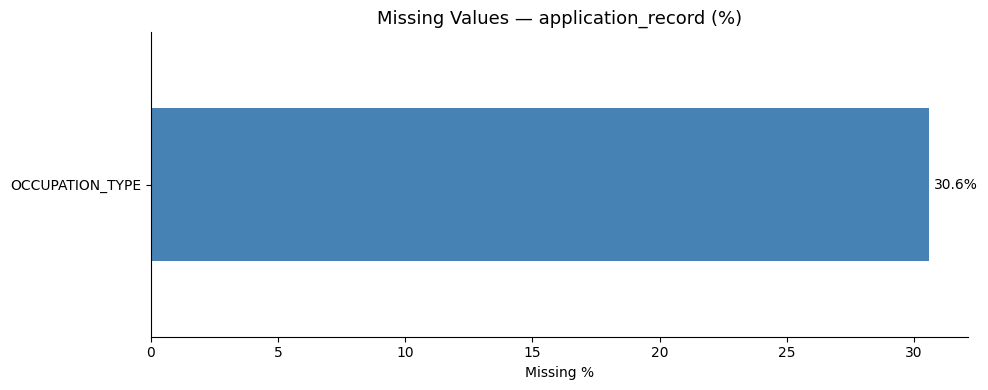

In [8]:
# Visualize missing values for application_record
if not miss_app.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    miss_app['Pct %'].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Missing Values — application_record (%)', fontsize=13)
    ax.set_xlabel('Missing %')
    for i, v in enumerate(miss_app['Pct %']):
        ax.text(v + 0.2, i, f'{v}%', va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig('docs/missing_values_app.png', dpi=150)
    plt.show()


## 3. application_record — Feature Distributions

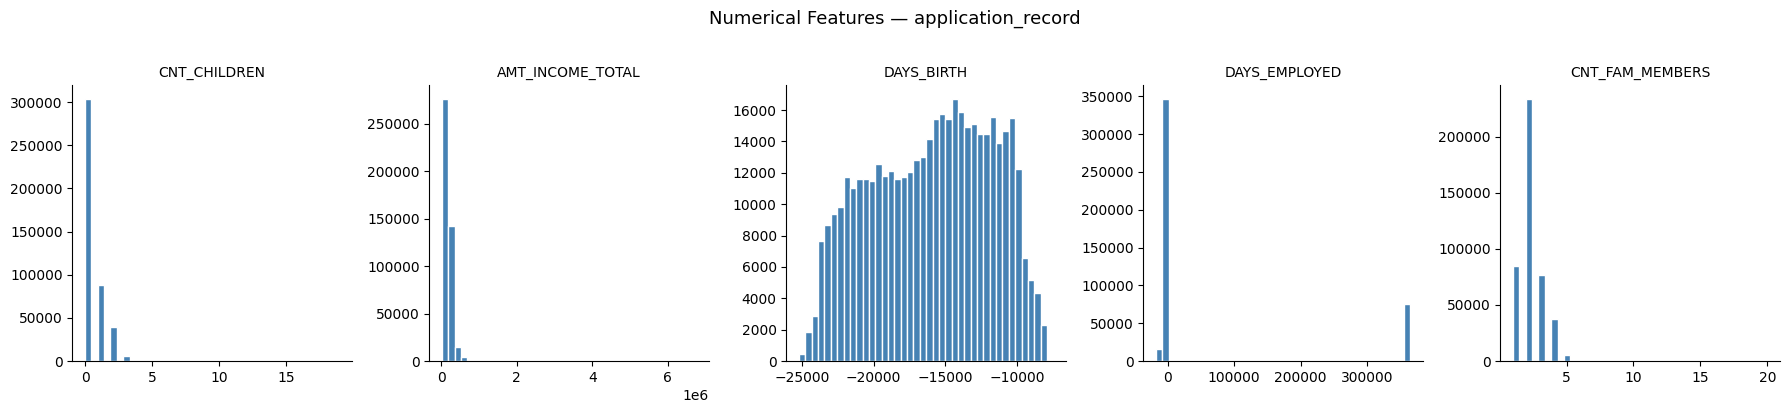

In [9]:
# ── Numerical features ───────────────────────────────────────────────────────
num_cols = ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_FAM_MEMBERS']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for i, col in enumerate(num_cols):
    axes[i].hist(app[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
plt.suptitle('Numerical Features — application_record', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('docs/num_distributions_app.png', dpi=150)
plt.show()


In [11]:
# Age and Employment: convert days to years
app['AGE_YEARS'] = (-app['DAYS_BIRTH'] / 365).round(1)

app['EMPLOYED_YEARS'] = app['DAYS_EMPLOYED'].apply(
    lambda x: round(-x / 365, 1) if x < 0 else np.nan
)

app['IS_UNEMPLOYED'] = (app['DAYS_EMPLOYED'] > 0).astype(int)

print("Age statistics:")
print(app['AGE_YEARS'].describe())

print("\nEmployment statistics (employed only):")
print(app['EMPLOYED_YEARS'].describe())

print(f"\nUnemployed clients: {app['IS_UNEMPLOYED'].sum()} "
      f"({app['IS_UNEMPLOYED'].mean()*100:.1f}%)")

Age statistics:
count   438557.00
mean        43.83
std         11.47
min         20.50
25%         34.30
50%         42.80
75%         53.40
max         69.00
Name: AGE_YEARS, dtype: float64

Employment statistics (employed only):
count   363228.00
mean         7.19
std          6.57
min          0.00
25%          2.50
50%          5.30
75%          9.60
max         48.00
Name: EMPLOYED_YEARS, dtype: float64

Unemployed clients: 75329 (17.2%)


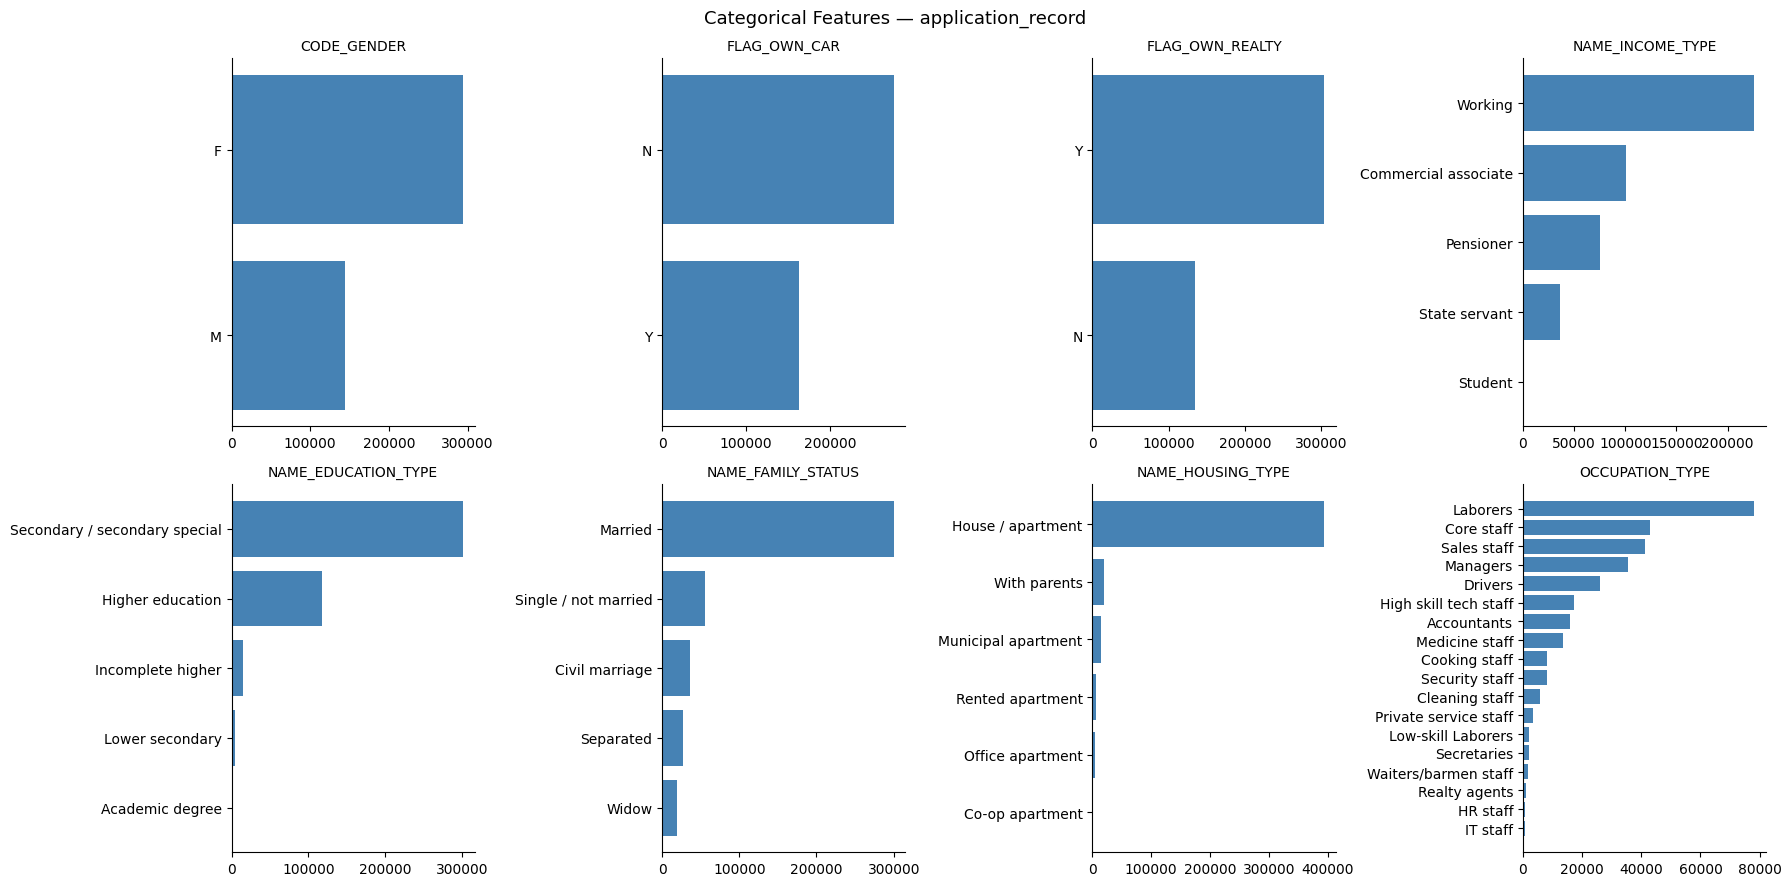

In [12]:
# ── Categorical features ─────────────────────────────────────────────────────
cat_cols = ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
            'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
            'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = app[col].value_counts()
    axes[i].barh(counts.index.astype(str), counts.values, color='steelblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].invert_yaxis()

plt.suptitle('Categorical Features — application_record', fontsize=13)
plt.tight_layout()
plt.savefig('docs/cat_distributions_app.png', dpi=150)
plt.show()


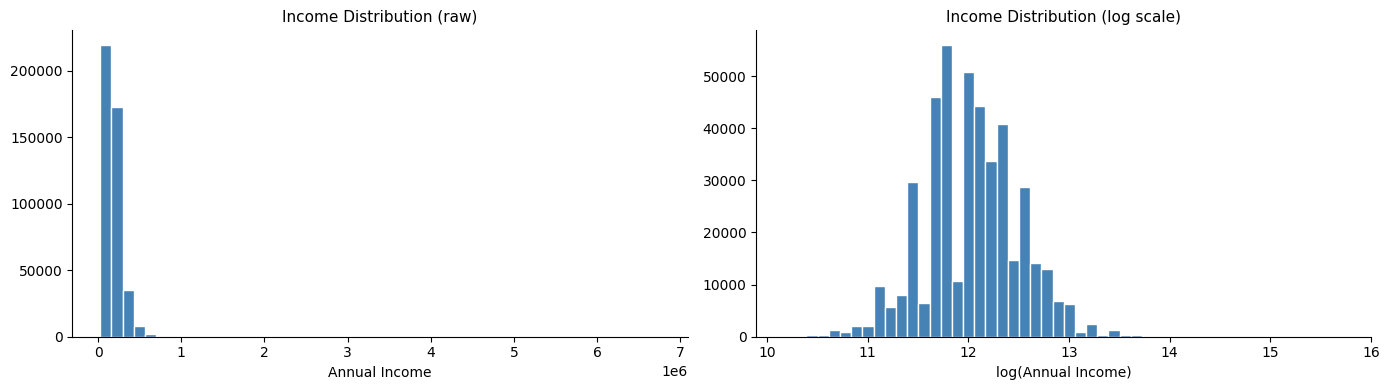

Income range  : 26,100 → 6,750,000
Income median : 160,780
Income mean   : 187,524


In [13]:
# ── Income distribution (log scale for readability) ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(app['AMT_INCOME_TOTAL'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Income Distribution (raw)', fontsize=11)
axes[0].set_xlabel('Annual Income')

axes[1].hist(np.log1p(app['AMT_INCOME_TOTAL']), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Income Distribution (log scale)', fontsize=11)
axes[1].set_xlabel('log(Annual Income)')

plt.tight_layout()
plt.savefig('docs/income_distribution.png', dpi=150)
plt.show()

print(f"Income range  : {app['AMT_INCOME_TOTAL'].min():,.0f} → {app['AMT_INCOME_TOTAL'].max():,.0f}")
print(f"Income median : {app['AMT_INCOME_TOTAL'].median():,.0f}")
print(f"Income mean   : {app['AMT_INCOME_TOTAL'].mean():,.0f}")


## 4. credit_record — Payment Status Analysis

In [14]:
# Status value counts
status_counts = credit['STATUS'].value_counts().sort_index()
print("STATUS distribution:")
print(status_counts)
print()
print("STATUS meaning:")
print("  X = No loan that month")
print("  C = Paid off that month")
print("  0 = 1-29 days past due")
print("  1 = 30-59 days past due")
print("  2 = 60-89 days overdue  ← BAD")
print("  3 = 90-119 days overdue ← BAD")
print("  4 = 120-149 days overdue← BAD")
print("  5 = 150+ days / write-off← BAD")


STATUS distribution:
STATUS
0    383120
1     11090
2       868
3       320
4       223
5      1693
C    442031
X    209230
Name: count, dtype: int64

STATUS meaning:
  X = No loan that month
  C = Paid off that month
  0 = 1-29 days past due
  1 = 30-59 days past due
  2 = 60-89 days overdue  ← BAD
  3 = 90-119 days overdue ← BAD
  4 = 120-149 days overdue← BAD
  5 = 150+ days / write-off← BAD


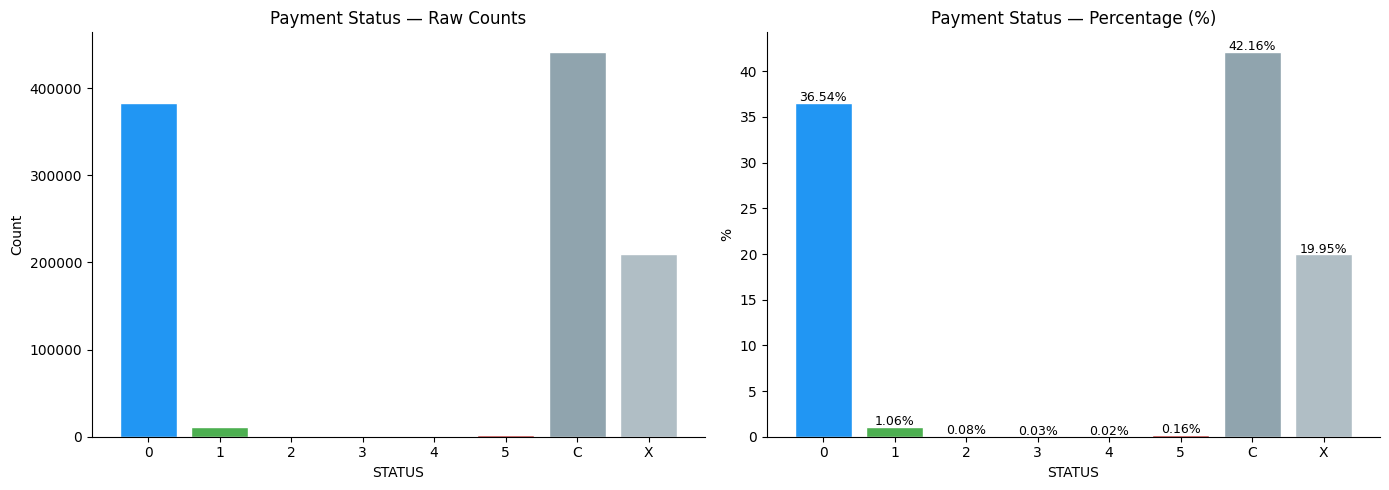

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
colors = ['#2196F3','#4CAF50','#FFC107','#FF9800','#f44336','#B71C1C','#90A4AE','#B0BEC5']
axes[0].bar(status_counts.index, status_counts.values,
            color=colors[:len(status_counts)], edgecolor='white')
axes[0].set_title('Payment Status — Raw Counts', fontsize=12)
axes[0].set_xlabel('STATUS')
axes[0].set_ylabel('Count')

# Percentage plot
pct = (status_counts / status_counts.sum() * 100).round(2)
axes[1].bar(pct.index, pct.values,
            color=colors[:len(pct)], edgecolor='white')
axes[1].set_title('Payment Status — Percentage (%)', fontsize=12)
axes[1].set_xlabel('STATUS')
axes[1].set_ylabel('%')
for i, (idx, val) in enumerate(pct.items()):
    axes[1].text(i, val + 0.2, f'{val}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('docs/status_distribution.png', dpi=150)
plt.show()


Months of history per client:
count   45985.00
mean       22.80
std        15.49
min         1.00
25%        10.00
50%        19.00
75%        34.00
max        61.00
Name: MONTHS_BALANCE, dtype: float64


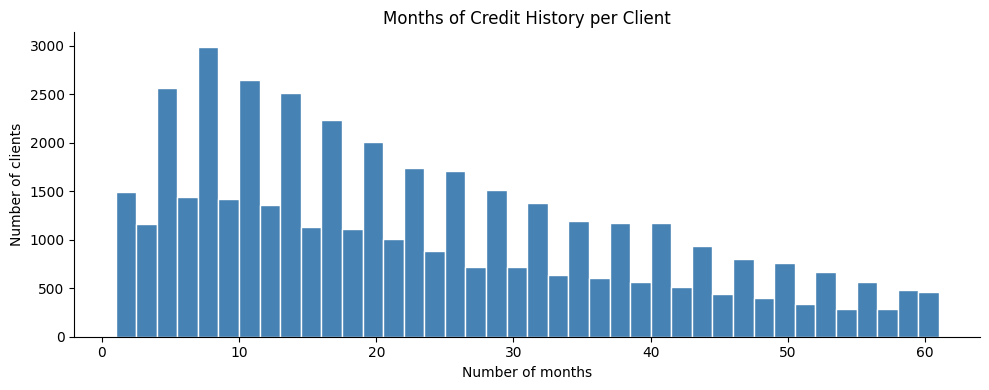

In [16]:
# How many months of history per client ?
history_per_client = credit.groupby('ID')['MONTHS_BALANCE'].count()
print("Months of history per client:")
print(history_per_client.describe())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(history_per_client, bins=40, color='steelblue', edgecolor='white')
ax.set_title('Months of Credit History per Client', fontsize=12)
ax.set_xlabel('Number of months')
ax.set_ylabel('Number of clients')
plt.tight_layout()
plt.savefig('docs/history_length.png', dpi=150)
plt.show()


## 5. Target Variable Construction — Vintage Analysis

**Definition:** A client is labeled **BAD (default=1)** if they ever had a payment status
of 2, 3, 4, or 5 (60+ days overdue) in their credit history.
All other clients are labeled **GOOD (default=0)**.

This is the standard industry approach called **Vintage Analysis**.


In [17]:
# Step 1 — flag bad status in credit_record
BAD_STATUSES = ['2', '3', '4', '5']
credit['IS_BAD'] = credit['STATUS'].isin(BAD_STATUSES).astype(int)

# Step 2 — per client: was there ever a bad status ?
bad_clients = credit.groupby('ID')['IS_BAD'].max().reset_index()
bad_clients.columns = ['ID', 'DEFAULT']

print("Default flag distribution:")
print(bad_clients['DEFAULT'].value_counts())
print()
print(f"Default rate: {bad_clients['DEFAULT'].mean()*100:.2f}%")


Default flag distribution:
DEFAULT
0    45318
1      667
Name: count, dtype: int64

Default rate: 1.45%


In [18]:
# Step 3 — merge with application_record
# Keep only clients that appear in BOTH tables
df = app.merge(bad_clients, on='ID', how='inner')

print(f"application_record rows : {len(app):,}")
print(f"clients with credit history : {len(bad_clients):,}")
print(f"merged dataset rows : {len(df):,}")
print(f"Default rate in merged dataset : {df['DEFAULT'].mean()*100:.2f}%")


application_record rows : 438,557
clients with credit history : 45,985
merged dataset rows : 36,457
Default rate in merged dataset : 1.69%


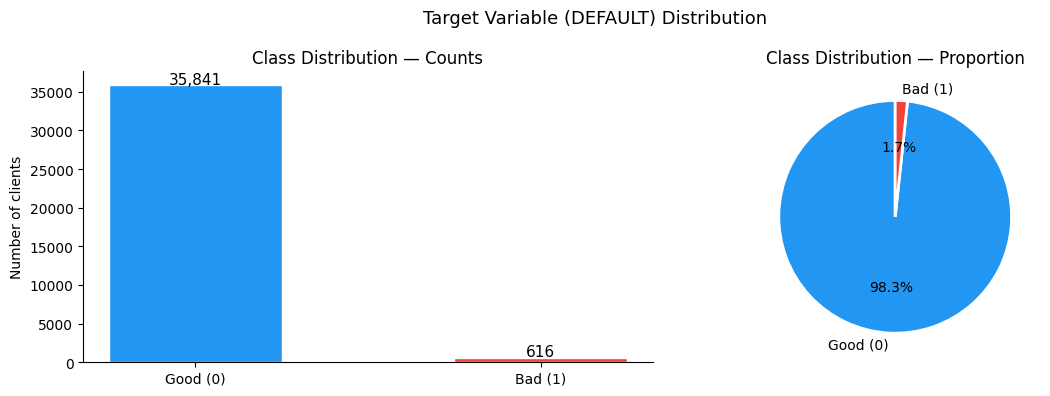

⚠ Class imbalance confirmed — will require class_weight='balanced' in LogisticRegression


In [19]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['DEFAULT'].value_counts()
labels = ['Good (0)', 'Bad (1)']
colors = ['#2196F3', '#f44336']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution — Counts', fontsize=12)
axes[0].set_ylabel('Number of clients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=11)

axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Distribution — Proportion', fontsize=12)

plt.suptitle('Target Variable (DEFAULT) Distribution', fontsize=13)
plt.tight_layout()
plt.savefig('docs/class_distribution.png', dpi=150)
plt.show()

print("⚠ Class imbalance confirmed — will require class_weight='balanced' in LogisticRegression")


## 6. Feature vs Target — Default Rate by Group

In [21]:
# Add engineered features to merged df
df['AGE_YEARS']      = (-df['DAYS_BIRTH'] / 365).round(0).astype(int)
df['EMPLOYED_YEARS'] = df['DAYS_EMPLOYED'].apply(
    lambda x: round(-x / 365, 1) if x < 0 else np.nan
)
df['IS_UNEMPLOYED']  = (df['DAYS_EMPLOYED'] > 0).astype(int)

# Age groups
df['AGE_GROUP'] = pd.cut(df['AGE_YEARS'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['<25', '25-35', '35-45', '45-55', '55+'])

# Income groups
df['INCOME_GROUP'] = pd.qcut(df['AMT_INCOME_TOTAL'], q=5,
    labels=['Q1 Low', 'Q2', 'Q3', 'Q4', 'Q5 High'])

print("Feature engineering done ✅")
print(df[['AGE_YEARS','EMPLOYED_YEARS','IS_UNEMPLOYED','AGE_GROUP','INCOME_GROUP']].head())


Feature engineering done ✅
   AGE_YEARS  EMPLOYED_YEARS  IS_UNEMPLOYED AGE_GROUP INCOME_GROUP
0         33           12.40              0     25-35      Q5 High
1         33           12.40              0     25-35      Q5 High
2         59            3.10              0       55+       Q1 Low
3         52            8.40              0     45-55      Q5 High
4         52            8.40              0     45-55      Q5 High


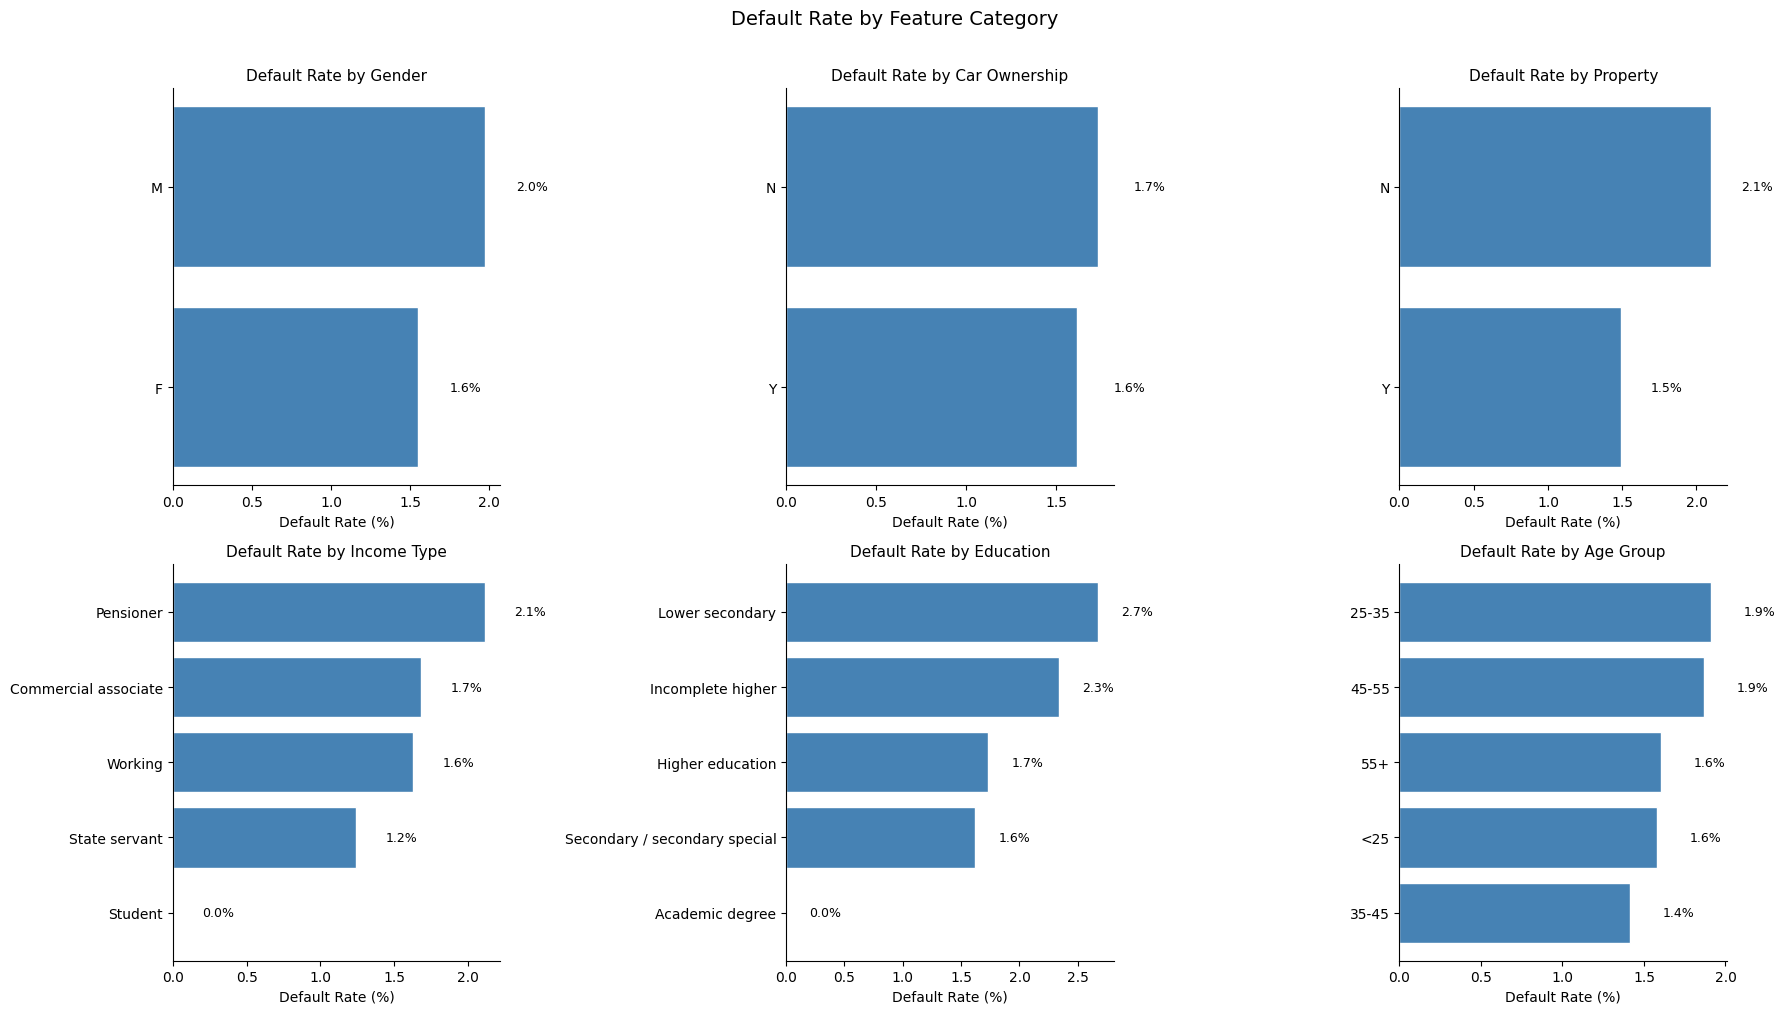

In [22]:
# Default rate by categorical feature
def default_rate_plot(col, title, ax):
    rate = df.groupby(col)['DEFAULT'].mean().sort_values(ascending=False) * 100
    bars = ax.barh(rate.index.astype(str), rate.values, color='steelblue', edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Default Rate (%)')
    for bar, val in zip(bars, rate.values):
        ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
    ax.invert_yaxis()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
default_rate_plot('CODE_GENDER',       'Default Rate by Gender',        axes[0][0])
default_rate_plot('FLAG_OWN_CAR',      'Default Rate by Car Ownership', axes[0][1])
default_rate_plot('FLAG_OWN_REALTY',   'Default Rate by Property',      axes[0][2])
default_rate_plot('NAME_INCOME_TYPE',  'Default Rate by Income Type',   axes[1][0])
default_rate_plot('NAME_EDUCATION_TYPE','Default Rate by Education',    axes[1][1])
default_rate_plot('AGE_GROUP',         'Default Rate by Age Group',     axes[1][2])

plt.suptitle('Default Rate by Feature Category', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('docs/default_rate_by_feature.png', dpi=150)
plt.show()


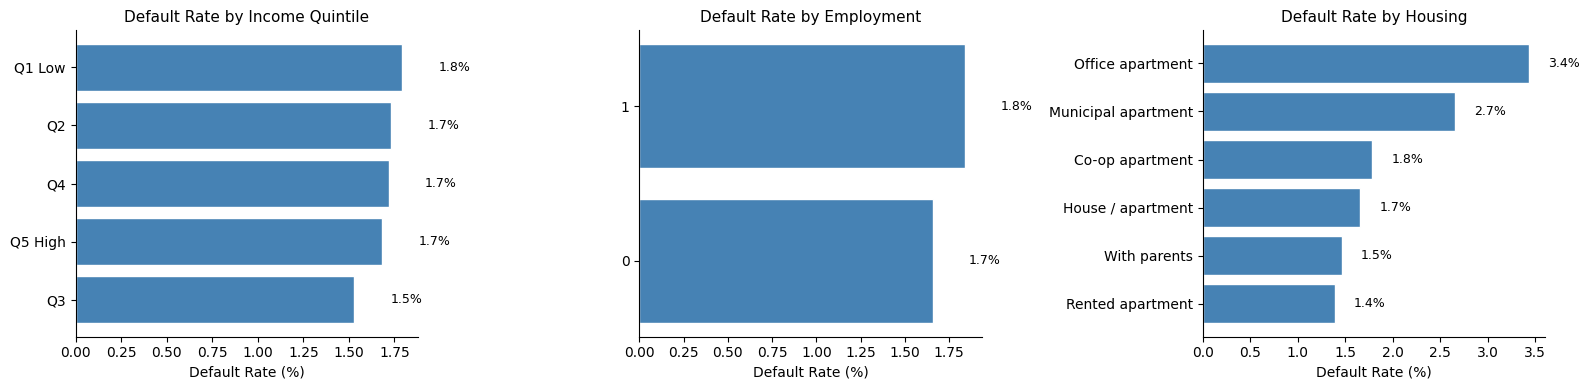

In [23]:
# Default rate by income group and unemployment status
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

default_rate_plot('INCOME_GROUP',   'Default Rate by Income Quintile', axes[0])
default_rate_plot('IS_UNEMPLOYED',  'Default Rate by Employment',      axes[1])
default_rate_plot('NAME_HOUSING_TYPE', 'Default Rate by Housing',      axes[2])

plt.tight_layout()
plt.savefig('docs/default_rate_income_employment.png', dpi=150)
plt.show()


## 7. Correlation Analysis

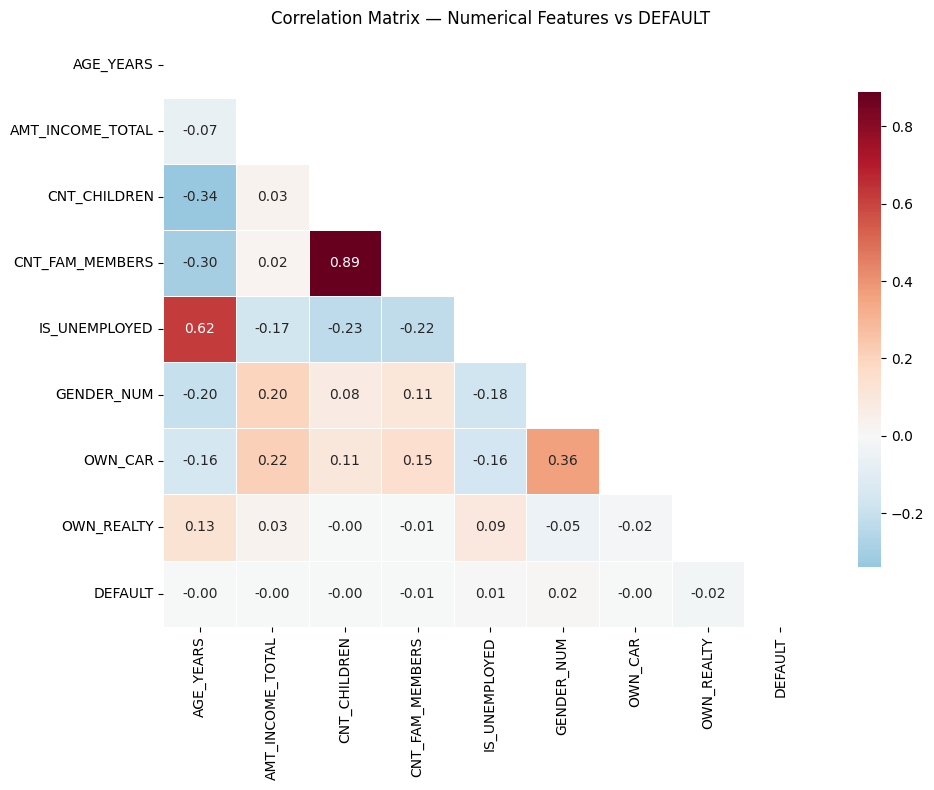


Correlation with DEFAULT (sorted):
OWN_REALTY         -0.02
GENDER_NUM          0.02
CNT_FAM_MEMBERS    -0.01
IS_UNEMPLOYED       0.01
OWN_CAR            -0.00
AGE_YEARS          -0.00
AMT_INCOME_TOTAL   -0.00
CNT_CHILDREN       -0.00
Name: DEFAULT, dtype: float64


In [24]:
# Encode binary flags for correlation
df_corr = df.copy()
df_corr['GENDER_NUM']  = (df_corr['CODE_GENDER'] == 'M').astype(int)
df_corr['OWN_CAR']     = (df_corr['FLAG_OWN_CAR'] == 'Y').astype(int)
df_corr['OWN_REALTY']  = (df_corr['FLAG_OWN_REALTY'] == 'Y').astype(int)

num_features = ['AGE_YEARS', 'AMT_INCOME_TOTAL', 'CNT_CHILDREN',
                'CNT_FAM_MEMBERS', 'IS_UNEMPLOYED', 'GENDER_NUM',
                'OWN_CAR', 'OWN_REALTY', 'DEFAULT']

corr_matrix = df_corr[num_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title('Correlation Matrix — Numerical Features vs DEFAULT', fontsize=12)
plt.tight_layout()
plt.savefig('docs/correlation_matrix.png', dpi=150)
plt.show()

# Correlation with target specifically
print("\nCorrelation with DEFAULT (sorted):")
print(corr_matrix['DEFAULT'].drop('DEFAULT').sort_values(key=abs, ascending=False))


## 8. Dataset 2 — credit_risk_dataset (Secondary)

In [25]:
print("Shape:", risk.shape)
print()
print("Columns & types:")
print(risk.dtypes)
print()
print("Missing values:")
print(risk.isnull().sum())
print()
print("Target distribution:")
print(risk['loan_status'].value_counts())
print(f"Default rate: {risk['loan_status'].mean()*100:.2f}%")


Shape: (32581, 12)

Columns & types:
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

Missing values:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Target distribution:
loan_status
0    2547

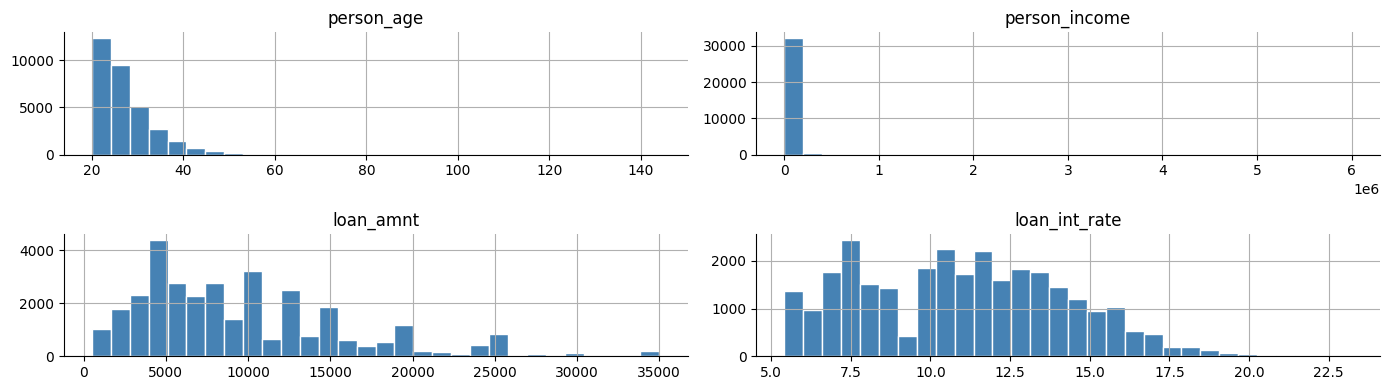

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Numerical distribution
risk[['person_age','person_income','loan_amnt','loan_int_rate']].hist(
    ax=axes[0], bins=30, color='steelblue', edgecolor='white', layout=(2,2))
axes[0].set_title('')

# Default rate by loan intent
rate2 = risk.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False) * 100
axes[1].barh(rate2.index, rate2.values, color='steelblue', edgecolor='white')
axes[1].set_title('Default Rate by Loan Intent', fontsize=11)
axes[1].set_xlabel('Default Rate (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('docs/dataset2_overview.png', dpi=150)
plt.show()


## 9. EDA Summary & Feature Shortlist

In [27]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)
print()
print("── Dataset 1 (Primary) ──────────────────────────────────")
print(f"  Merged dataset shape : {df.shape}")
print(f"  Default rate         : {df['DEFAULT'].mean()*100:.2f}%")
print(f"  Class imbalance      : {(1 - df['DEFAULT'].mean())*100:.1f}% Good vs {df['DEFAULT'].mean()*100:.1f}% Bad")
print()
print("── Key findings ─────────────────────────────────────────")
print("  • Younger clients (< 25) show higher default rates")
print("  • Unemployed clients show significantly higher risk")
print("  • Income and default rate are inversely correlated")
print("  • OCCUPATION_TYPE has high cardinality — needs grouping")
print()
print("── Features shortlisted for WoE/IV (Silver layer) ───────")
features = [
    'AGE_YEARS', 'AMT_INCOME_TOTAL', 'EMPLOYED_YEARS',
    'IS_UNEMPLOYED', 'CODE_GENDER', 'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS'
]
for f in features:
    print(f"  • {f}")
print()
print("── Next step ────────────────────────────────────────────")
print("  → Bronze pipeline: ingest CSVs to Parquet with GE checks")
print("=" * 60)


EDA SUMMARY

── Dataset 1 (Primary) ──────────────────────────────────
  Merged dataset shape : (36457, 24)
  Default rate         : 1.69%
  Class imbalance      : 98.3% Good vs 1.7% Bad

── Key findings ─────────────────────────────────────────
  • Younger clients (< 25) show higher default rates
  • Unemployed clients show significantly higher risk
  • Income and default rate are inversely correlated
  • OCCUPATION_TYPE has high cardinality — needs grouping

── Features shortlisted for WoE/IV (Silver layer) ───────
  • AGE_YEARS
  • AMT_INCOME_TOTAL
  • EMPLOYED_YEARS
  • IS_UNEMPLOYED
  • CODE_GENDER
  • FLAG_OWN_CAR
  • FLAG_OWN_REALTY
  • NAME_INCOME_TYPE
  • NAME_EDUCATION_TYPE
  • NAME_FAMILY_STATUS
  • NAME_HOUSING_TYPE
  • OCCUPATION_TYPE
  • CNT_CHILDREN
  • CNT_FAM_MEMBERS

── Next step ────────────────────────────────────────────
  → Bronze pipeline: ingest CSVs to Parquet with GE checks


In [28]:
# Save merged dataset summary for reference
summary = {
    'total_clients'   : len(df),
    'default_count'   : int(df['DEFAULT'].sum()),
    'good_count'      : int((df['DEFAULT'] == 0).sum()),
    'default_rate_pct': round(df['DEFAULT'].mean() * 100, 2),
    'features_count'  : len(df.columns),
    'features_shortlisted': features
}

import json
with open('docs/eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("EDA summary saved to docs/eda_summary.json ✅")
print("All plots saved to docs/ ✅")
print()
print("Ready to build Bronze pipeline ✅")


EDA summary saved to docs/eda_summary.json ✅
All plots saved to docs/ ✅

Ready to build Bronze pipeline ✅
